In [14]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
N1 = 1000000
kappa_range = (np.linspace(-1, 1, 20))**3
max_new = 0.115+0.003
min_new = 0.115-0.003
kappa_range = (kappa_range-kappa_range.min()) * (max_new - min_new) / 2 + min_new

num_ensambles = 3000
M1 = np.empty((len(kappa_range), num_ensambles))
for n in range(num_ensambles):
    with open('results/{0}_{1}_rho_sub_critical.p'.format(n, N1), "rb") as f:
        mags = pickle.load(f)
        for k in range(len(kappa_range)):
            m = mags[k]
            M1[k,n] = m

In [16]:
N2 = 100000

num_ensambles = 10000
M2 = np.empty(num_ensambles)
for n in range(num_ensambles):
    with open('results/{0}_{1}_fig7_rho_sub_critical.p'.format(n, N2), "rb") as f:
        mag = pickle.load(f)
        M2[n] = mag

FileNotFoundError: [Errno 2] No such file or directory: 'results/10000_100000_fig7_rho_sub_critical.p'

In [4]:
N3 = 145923

num_ensambles = 10000
M3 = np.empty(num_ensambles)
for n in range(num_ensambles):
    with open('results/{0}_{1}_fig7_rho_sub_critical.p'.format(n, N3), "rb") as f:
        mag = pickle.load(f)
        M3[n] = mag

In [5]:
N4 = 212936

num_ensambles = 10000
M4 = np.empty(num_ensambles)
for n in range(num_ensambles):
    with open('results/{0}_{1}_fig7_rho_sub_critical.p'.format(n, N4), "rb") as f:
        mag = pickle.load(f)
        M4[n] = mag

In [6]:
N5 = 310723

num_ensambles = 10000
M5 = np.empty(num_ensambles)
for n in range(num_ensambles):
    with open('results/{0}_{1}_fig7_rho_sub_critical.p'.format(n, N5), "rb") as f:
        mag = pickle.load(f)
        M5[n] = mag

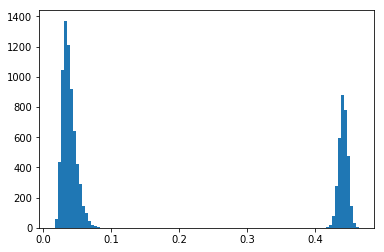

In [7]:
plt.hist(M5, bins=100)
plt.show()

In [8]:
m0 = 0.0559263564072972
cutoff = 0.25
m0_1M = m0-np.mean(M1[10][M1[10]<cutoff])
m0_100k = m0-np.mean(M2[M2 < cutoff])
m0_146k = m0-np.mean(M3[M3 < cutoff])
m0_213k = m0-np.mean(M4[M4 < cutoff])
m0_311k = m0-np.mean(M5[M5 < cutoff])

In [9]:
z = np.polyfit(np.log([N1,N2,N3,N4,N5]), np.log([m0_1M, m0_100k, m0_146k, m0_213k, m0_311k]), 1)
print(z)
p = np.poly1d(z)

[-0.18508511 -1.71478324]


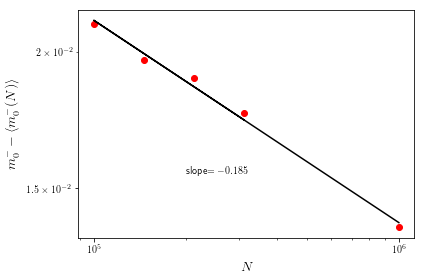

In [10]:
plt.rc('text', usetex=True)
plt.loglog([N1,N2,N3,N4,N5], [m0_1M, m0_100k, m0_146k, m0_213k, m0_311k], 'ro')
plt.loglog([N1,N2,N3,N4,N5], np.exp(p(np.log([N1,N2,N3,N4,N5]))), 'k-')
plt.yticks([1.5e-2], [r"$1.5\times10^{-2}$"])
plt.text(2e5, 1.55e-2, r'slope$={0:.3f}$'.format(z[0]))
plt.xlabel('$N$', fontsize=14)
plt.ylabel(r'$m_0^--\langle m_0^-(N)\rangle$', fontsize=14)
#plt.grid()
plt.tight_layout()
plt.savefig('fig7_10ksamples.pdf', dpi=300)
plt.show()

In [11]:
X_1M = N1*(np.mean(M1[10][M1[10]<cutoff]**2)-np.mean(M1[10][M1[10]<cutoff])**2)
X_100k = N2*(np.mean(M2[M2 < cutoff]**2)-np.mean(M2[M2 < cutoff])**2)
X_146k = N3*(np.mean(M3[M3 < cutoff]**2)-np.mean(M3[M3 < cutoff])**2)
X_213k = N4*(np.mean(M4[M4 < cutoff]**2)-np.mean(M4[M4 < cutoff])**2)
X_311k = N5*(np.mean(M5[M5 < cutoff]**2)-np.mean(M5[M5 < cutoff])**2)

In [12]:
z = np.polyfit(np.log([N1,N2,N3,N4,N5]), np.log([X_1M, X_100k, X_146k, X_213k, X_311k]), 1)
print(z)
p = np.poly1d(z)

[ 0.56039762 -3.64963003]


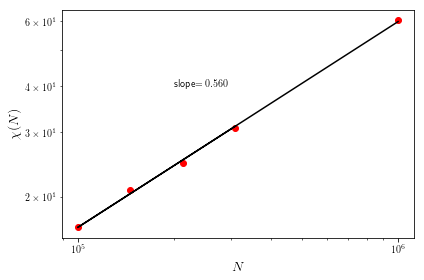

In [13]:
plt.loglog([N1,N2,N3,N4,N5], [X_1M, X_100k, X_146k, X_213k, X_311k], 'ro')
plt.loglog([N1,N2,N3,N4,N5], np.exp(p(np.log([N1,N2,N3,N4,N5]))), 'k-')
#plt.xticks([1.5e-2], [r"$1.5\times10^{-2}$"])
plt.text(2e5, 4e1, r'slope$={0:.3f}$'.format(z[0]))
plt.xlabel('$N$', fontsize=14)
plt.ylabel(r'$\chi(N)$', fontsize=14)
#plt.grid()
plt.tight_layout()
plt.savefig('fig8_10ksamples.pdf', dpi=300)
plt.show()